In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
data_file = 'tmp_mc_train_test/rnn_recon_v4_epoch3_final_examples.npz'
data = np.load(data_file)

In [4]:
target = data['target'] # (n_examples, seq_len)
recon_mean = data['recon_mean'] # (n_examples, seq_len)
mask = data['mask'] # (n_examples, seq_len)
samples = data['samples'] # (num_samples, n_examples, seq_len)

### Plot example

#### Shade masked regions

In [ ]:
def shade_regions(ax, t, mask_bool):
    """Shade only masked (True) contiguous segments without gaps.

    Uses t[idx] as the end boundary so adjacent segments touch.
    """
    labeled_mask = False
    n = len(mask_bool)
    if n == 0:
        return
    cur = mask_bool[0]
    start = 0
    for idx in range(1, n):
        if mask_bool[idx] != cur:
            if cur:
                x0 = float(t[start])
                x1 = float(t[idx])
                ax.axvspan(x0, x1, color='red', alpha=0.10, zorder=0, label='Masked region' if not labeled_mask else None)
                labeled_mask = True
            start = idx
            cur = mask_bool[idx]
    # last segment
    if cur:
        x0 = float(t[start])
        x1 = float(t[-1])
        ax.axvspan(x0, x1, color='red', alpha=0.10, zorder=0, label='Masked region' if not labeled_mask else None)

#### Plot

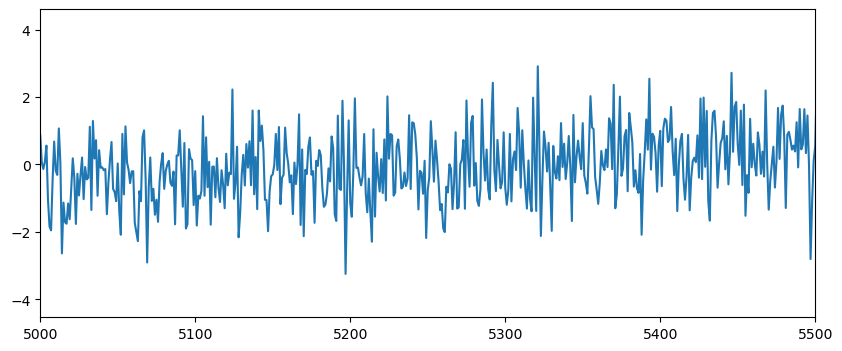

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(target[1], label='Target')
plt.xlim(5000,5500)
plt.show()